In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [16]:
df = pd.read_csv('water_potability_clean.csv')
print(f"Dataset shape: {df.shape}")

Dataset shape: (3276, 10)


In [17]:
X = df.drop('Potability', axis=1)
y = df['Potability']

# podela na trening i test skup
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

# normalizacija
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# primena lda
lda = LDA(n_components=1)
X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_test_lda = lda.transform(X_test_scaled)


print(f"Shape of X_train_scaled: {X_train_scaled.shape}")
print(f"Shape of X_train_lda:    {X_train_lda.shape}")

Shape of X_train_scaled: (2784, 9)
Shape of X_train_lda:    (2784, 1)



Accuracy on original features: 0.6098

Classification Report on original features:
              precision    recall  f1-score   support

           0       0.61      1.00      0.76       300
           1       0.00      0.00      0.00       192

    accuracy                           0.61       492
   macro avg       0.30      0.50      0.38       492
weighted avg       0.37      0.61      0.46       492


Confusion Matrix on original features:


C:\Users\Iva\Desktop\water-potability-prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Iva\Desktop\water-potability-prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Iva\Desktop\water-potability-prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

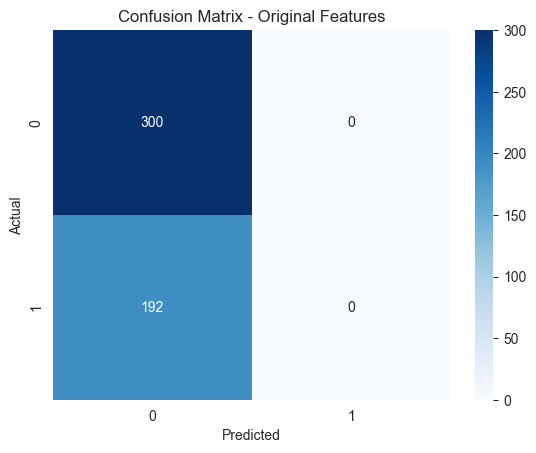

In [18]:
# log reg na originalnim obelezjima

# inicijalizacija i treniranje modela
log_reg_original = LogisticRegression(random_state=42)
log_reg_original.fit(X_train_scaled, y_train)

# predikcija na est skupu
y_pred_original = log_reg_original.predict(X_test_scaled)

# evaluacija performansi
accuracy_original = accuracy_score(y_test, y_pred_original)
print(f"\nAccuracy on original features: {accuracy_original:.4f}")

print("\nClassification Report on original features:")
print(classification_report(y_test, y_pred_original))

print("\nConfusion Matrix on original features:")
cm_original = confusion_matrix(y_test, y_pred_original)
sns.heatmap(cm_original, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Original Features')
plt.show()


Accuracy on LDA features: 0.6098

Classification Report on LDA features:
              precision    recall  f1-score   support

           0       0.61      1.00      0.76       300
           1       0.00      0.00      0.00       192

    accuracy                           0.61       492
   macro avg       0.30      0.50      0.38       492
weighted avg       0.37      0.61      0.46       492


Confusion Matrix on LDA features:


C:\Users\Iva\Desktop\water-potability-prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Iva\Desktop\water-potability-prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Iva\Desktop\water-potability-prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

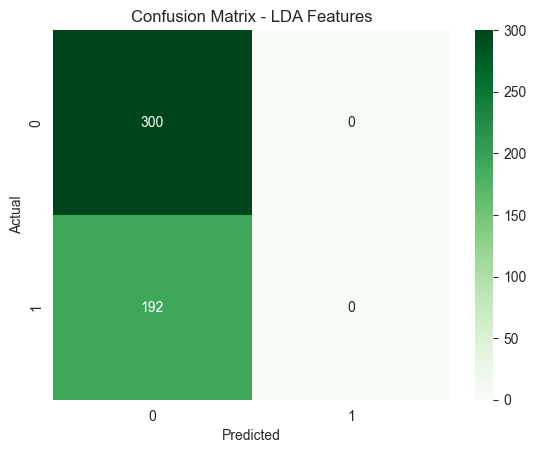

In [19]:
# log reg na LDA obelezjima

log_reg_lda = LogisticRegression(random_state=42)
log_reg_lda.fit(X_train_lda, y_train)

y_pred_lda = log_reg_lda.predict(X_test_lda)

accuracy_lda = accuracy_score(y_test, y_pred_lda)
print(f"\nAccuracy on LDA features: {accuracy_lda:.4f}")

print("\nClassification Report on LDA features:")
print(classification_report(y_test, y_pred_lda))

print("\nConfusion Matrix on LDA features:")
cm_lda = confusion_matrix(y_test, y_pred_lda)
sns.heatmap(cm_lda, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - LDA Features')
plt.show()

In [20]:
# podseavanje hiperparametara pomocu grid searcha

from sklearn.model_selection import GridSearchCV

# Definišemo prostor hiperparametara koje želimo da testiramo
# 'C' je inverzna jačina regularizacije (manje vrednosti = jača regularizacija)
# 'penalty' je tip regularizacije
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'] # 'liblinear' je dobar solver koji podržava i l1 i l2
}

# --- 1. GridSearchCV na ORIGINALNIM obeležjima ---
print("--- Hyperparameter Tuning for Logistic Regression on Original Features ---")
grid_original = GridSearchCV(LogisticRegression(random_state=42, solver='liblinear'), param_grid, cv=5, scoring='accuracy')
grid_original.fit(X_train_scaled, y_train)

print(f"Best parameters for original features: {grid_original.best_params_}")
print(f"Best cross-validation accuracy: {grid_original.best_score_:.4f}")


# --- 2. GridSearchCV na LDA obeležjima ---
print("\n--- Hyperparameter Tuning for Logistic Regression on LDA Features ---")
grid_lda = GridSearchCV(LogisticRegression(random_state=42, solver='liblinear'), param_grid, cv=5, scoring='accuracy')
grid_lda.fit(X_train_lda, y_train)

print(f"Best parameters for LDA features: {grid_lda.best_params_}")
print(f"Best cross-validation accuracy: {grid_lda.best_score_:.4f}")

--- Hyperparameter Tuning for Logistic Regression on Original Features ---
Best parameters for original features: {'C': 0.001, 'penalty': 'l1', 'solver': 'liblinear'}
Best cross-validation accuracy: 0.6099

--- Hyperparameter Tuning for Logistic Regression on LDA Features ---
Best parameters for LDA features: {'C': 0.001, 'penalty': 'l1', 'solver': 'liblinear'}
Best cross-validation accuracy: 0.6099


--- Final Evaluation and Conclusion for Logistic Regression ---
Conclusion: The model with original features performed slightly better or equal in cross-validation.
Proceeding with the final test using the best model on original scaled features.

Final Model Details: LogisticRegression(C=0.001, penalty='l1', random_state=42, solver='liblinear')

Final Accuracy on the independent test set: 0.6098

Final Classification Report on the test set:
              precision    recall  f1-score   support

           0       0.61      1.00      0.76       300
           1       0.00      0.00      0.00       192

    accuracy                           0.61       492
   macro avg       0.30      0.50      0.38       492
weighted avg       0.37      0.61      0.46       492


Final Confusion Matrix on the test set:


C:\Users\Iva\Desktop\water-potability-prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Iva\Desktop\water-potability-prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Iva\Desktop\water-potability-prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

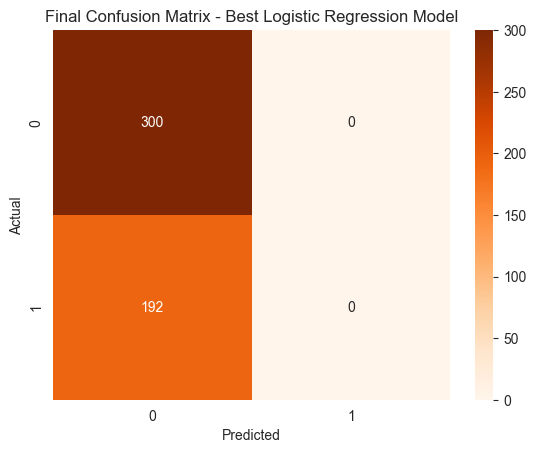

In [21]:

print("--- Final Evaluation and Conclusion for Logistic Regression ---")

# Upoređujemo rezultate unakrsne validacije da bismo izabrali konačni model
if grid_original.best_score_ >= grid_lda.best_score_:
    print("Conclusion: The model with original features performed slightly better or equal in cross-validation.")
    print("Proceeding with the final test using the best model on original scaled features.")

    # Preuzimamo najbolji model sa originalnim podacima
    final_model = grid_original.best_estimator_

    # Testiramo ga na finalnom test skupu
    final_predictions = final_model.predict(X_test_scaled)
    final_accuracy = accuracy_score(y_test, final_predictions)

else:
    print("Conclusion: The model with LDA-reduced features performed slightly better in cross-validation.")
    print("Proceeding with the final test using the best model on LDA features.")

    # Preuzimamo najbolji model sa LDA podacima
    final_model = grid_lda.best_estimator_

    # Testiramo ga na finalnom test skupu
    final_predictions = final_model.predict(X_test_lda)
    final_accuracy = accuracy_score(y_test, final_predictions)

print(f"\nFinal Model Details: {final_model}")
print(f"\nFinal Accuracy on the independent test set: {final_accuracy:.4f}")

print("\nFinal Classification Report on the test set:")
print(classification_report(y_test, final_predictions))

print("\nFinal Confusion Matrix on the test set:")
cm_final = confusion_matrix(y_test, final_predictions)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Oranges')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Final Confusion Matrix - Best Logistic Regression Model')
plt.show()